<a href="https://colab.research.google.com/github/mahieshwar-budati/neo4j_basic/blob/main/neo_graph__RAG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Install Libraries
!pip install neo4j networkx matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 325.3/325.3 kB 3.3 MB/s eta 0:00:00


In [ ]:
# Connect to Neo4j

from neo4j import GraphDatabase

URI = "neo4j+s://b163844d.databases.neo4j.io"
USERNAME = "b163844d"
PASSWORD = "hBzepwEJlyGnlFguKRZP7X8BsfoEZUKASqzls5TFcpo"
# createing the drive
driver = GraphDatabase.driver(URI, auth=(USERNAME, PASSWORD))

print("Connected to Neo4j 🚀")

Connected to Neo4j 🚀


In [ ]:
def fetch_graph_data():
    query = """
    MATCH (n)-[r]->(m)
    RETURN
        id(n) AS source_id,
        labels(n) AS source_labels,
        type(r) AS relationship,
        id(m) AS target_id,
        labels(m) AS target_labels
    """

    with driver.session() as session:
        result = session.run(query)
        return [record.data() for record in result]

data = fetch_graph_data()
print("Records:", len(data))
print(data)

Records: 4
[{'source_id': 0, 'source_labels': ['Person'], 'relationship': 'WORKS_AT', 'target_id': 2, 'target_labels': ['Company']}, {'source_id': 1, 'source_labels': ['Person'], 'relationship': 'FRIEND_OF', 'target_id': 0, 'target_labels': ['Person']}, {'source_id': 3, 'source_labels': ['Person'], 'relationship': 'WORKS_AT', 'target_id': 5, 'target_labels': ['Company']}, {'source_id': 4, 'source_labels': ['Person'], 'relationship': 'FRIEND_OF', 'target_id': 3, 'target_labels': ['Person']}]


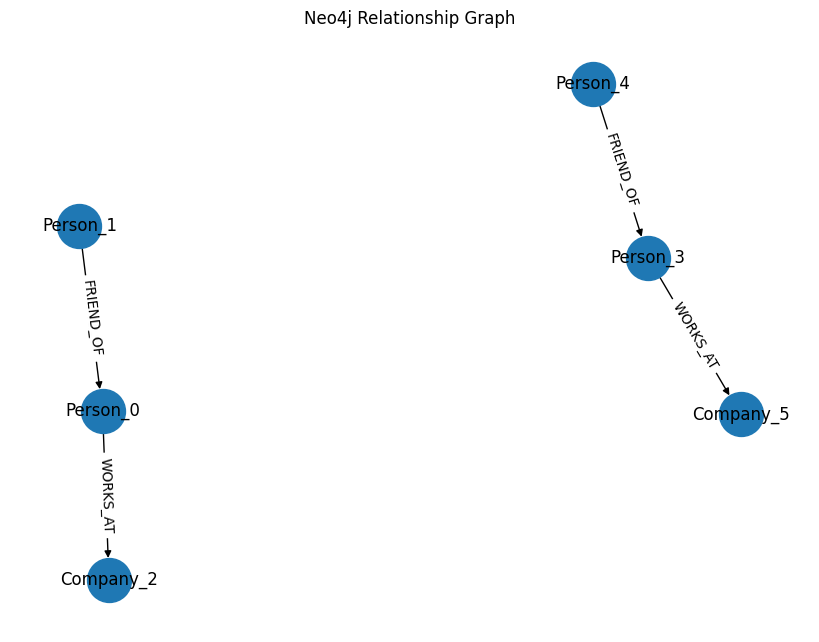

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

# Build graph from relationship data
for record in data:
    source = f"{record['source_labels'][0]}_{record['source_id']}"
    target = f"{record['target_labels'][0]}_{record['target_id']}"
    relationship = record["relationship"]

    G.add_edge(source, target, label=relationship)

plt.figure(figsize=(8,6))
pos = nx.spring_layout(G)

nx.draw(G, pos, with_labels=True, node_size=1000)

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.title("Neo4j Relationship Graph")
plt.show()

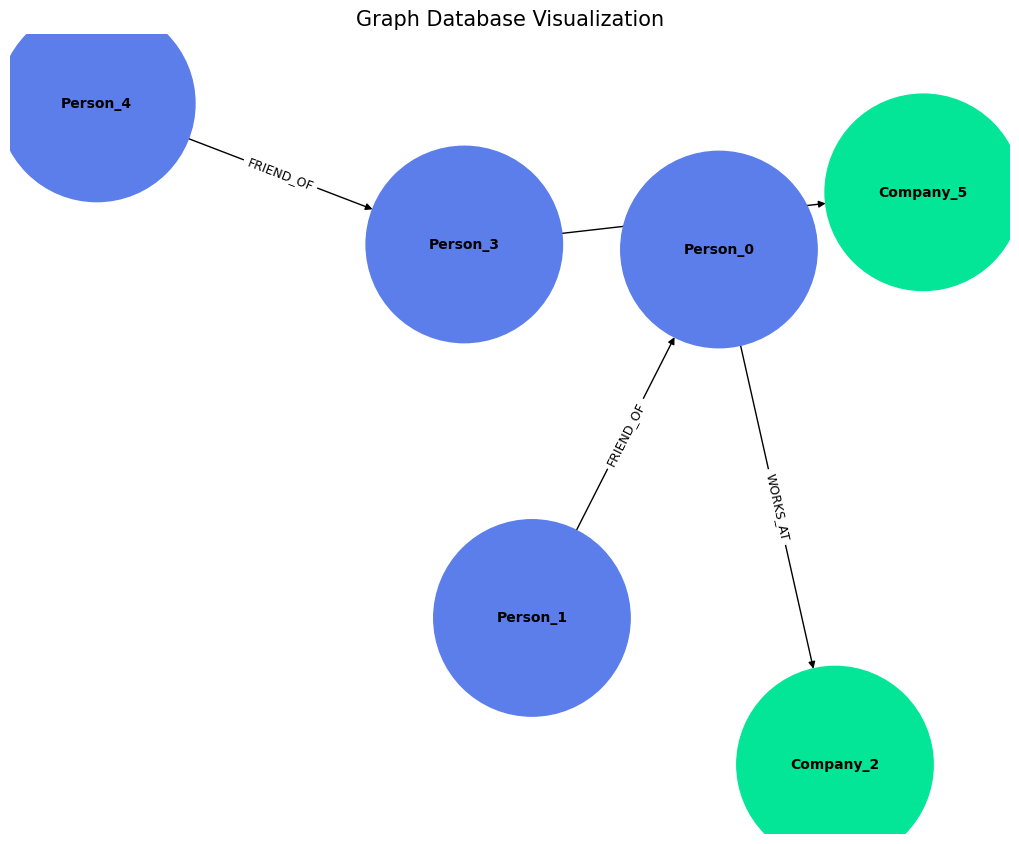

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
import random

G = nx.DiGraph()

labels_set = set()

# Build graph
for record in data:
    source_label = record['source_labels'][0]
    target_label = record['target_labels'][0]

    source = f"{source_label}_{record['source_id']}"
    target = f"{target_label}_{record['target_id']}"

    labels_set.add(source_label)
    labels_set.add(target_label)

    G.add_node(source, label=source_label)
    G.add_node(target, label=target_label)
    G.add_edge(source, target, label=record["relationship"])

# Assign unique color per label
color_map = {}
for label in labels_set:
    color_map[label] = (random.random(), random.random(), random.random())

node_colors = [color_map[G.nodes[node]['label']] for node in G.nodes()]

plt.figure(figsize=(10,8))

# Better spacing
pos = nx.spring_layout(G, k=1.2, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    node_size=20000,
    font_size=10,
    font_weight="bold"
)

edge_labels = nx.get_edge_attributes(G, 'label')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title("Graph Database Visualization", fontsize=15)
plt.axis("off")
plt.show()